In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]


import cv2
import numpy as np
import matplotlib.pyplot as plt

Saving 00098.png to 00098.png


In [ ]:
def unsharp_mask(
    image: np.ndarray,
    kernel_size: int = 5,
    amount: float = 1.0,
) -> np.ndarray:
    blurred = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    sharpened = image.astype(np.float32) + amount * (
        image.astype(np.float32) - blurred.astype(np.float32)
    )
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def add_salt_and_pepper_noise(
    image: np.ndarray,
    rng: np.random.Generator,
    amount_range: tuple[float, float],
    salt_ratio: float,
) -> np.ndarray:
    amount = rng.uniform(amount_range[0], amount_range[1])
    if amount <= 0:
        return image
    noisy = image.copy()
    height, width = image.shape[:2]
    mask = rng.random((height, width))
    pepper_threshold = amount * (1.0 - salt_ratio)
    salt_threshold = 1.0 - (amount * salt_ratio)
    if image.ndim == 2:
        noisy[mask < pepper_threshold] = 0
        noisy[mask > salt_threshold] = 255
    else:
        noisy[mask < pepper_threshold, :] = 0
        noisy[mask > salt_threshold, :] = 255
    return noisy


def random_blur(
    image: np.ndarray,
    rng: np.random.Generator,
    max_kernel_size: int,
    probability: float,
) -> np.ndarray:
    if max_kernel_size < 3 or rng.random() > probability:
        return image
    odd_kernel_sizes = list(range(3, max_kernel_size + 1, 2))
    kernel_size = int(rng.choice(odd_kernel_sizes))
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def show(image: np.ndarray, title: str) -> None:
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()


def add_gradient_brightness(
    image: np.ndarray,
    rng: np.random.Generator,
    strength_range: tuple[int, int],
) -> np.ndarray:
    height, width = image.shape[:2]
    if height < 1 or width < 1:
        return image
    yy, xx = np.mgrid[0:height, 0:width]
    start_x = rng.uniform(0, max(1, width - 1))
    start_y = rng.uniform(0, max(1, height - 1))
    direction = rng.uniform(0, 2 * np.pi)
    projection = (xx - start_x) * np.cos(direction) + (yy - start_y) * np.sin(direction)
    projection -= projection.min()
    max_projection = projection.max()
    if max_projection > 0:
        projection /= max_projection
    strength = int(rng.integers(strength_range[0], strength_range[1] + 1))
    gradient = projection * strength
    if image.ndim == 3:
        gradient = gradient[:, :, None]
    augmented = image.astype(np.float32) + gradient
    return np.clip(augmented, 0, 255).astype(np.uint8)


def random_rotate_scale(
    image: np.ndarray,
    rng: np.random.Generator,
    max_rotation_degrees: float,
    scale_range: tuple[float, float],
) -> np.ndarray:
    height, width = image.shape[:2]
    angle = rng.uniform(-max_rotation_degrees, max_rotation_degrees)
    scale = rng.uniform(scale_range[0], scale_range[1])
    center = ((width - 1) / 2.0, (height - 1) / 2.0)
    matrix = cv2.getRotationMatrix2D(center, angle, scale)
    border_value = median_border_value(image)
    return cv2.warpAffine(
        image,
        matrix,
        (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=border_value,
    )


def add_random_rectangles(
    image: np.ndarray,
    rng: np.random.Generator,
    count_range: tuple[int, int],
    brightness_range: tuple[int, int],
) -> np.ndarray:
    height, width = image.shape[:2]
    if height < 2 or width < 2:
        return image
    augmented = image.copy()
    min_count, max_count = count_range
    count = int(rng.integers(min_count, max_count + 1))
    upper_half_height = max(1, height // 2)
    for _ in range(count):
        rect_width = int(rng.integers(max(1, width // 12), max(2, width // 3) + 1))
        rect_height = int(
            rng.integers(max(1, upper_half_height // 12), max(2, upper_half_height // 3) + 1)
        )
        x1 = int(rng.integers(0, max(1, width - rect_width + 1)))
        y1 = int(rng.integers(0, max(1, upper_half_height - rect_height + 1)))
        x2 = min(width, x1 + rect_width)
        y2 = min(upper_half_height, y1 + rect_height)
        brightness_delta = int(rng.integers(brightness_range[0], brightness_range[1] + 1))
        region = augmented[y1:y2, x1:x2].astype(np.int16) + brightness_delta
        augmented[y1:y2, x1:x2] = np.clip(region, 0, 255).astype(np.uint8)
    return augmented


def median_border_value(image: np.ndarray) -> int | tuple[int, ...]:
    if image.ndim == 2:
        border = np.concatenate(
            [image[0, :], image[-1, :], image[:, 0], image[:, -1]]
        )
        return int(np.median(border))

    border = np.concatenate(
        [image[0, :, :], image[-1, :, :], image[:, 0, :], image[:, -1, :]],
        axis=0,
    )
    return tuple(int(value) for value in np.median(border, axis=0))


In [ ]:
seed = 42
max_blur_kernel_size = 31
blur_probability = 1.0
min_noise_amount = 0.15
max_noise_amount = 0.30
salt_ratio = 0.5
median_kernel_size = 5  # must be odd
unsharp_kernel_size = 5  # must be odd
unsharp_amount = 1.0
min_gradient_strength = 80
max_gradient_strength = 150
max_rotation_degrees = 25.0
min_scale = 0.7
max_scale = 1.3
min_rectangles = 3
max_rectangles = 6
min_rectangle_brightness = 80
max_rectangle_brightness = 150

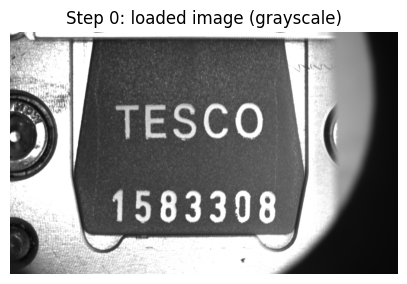

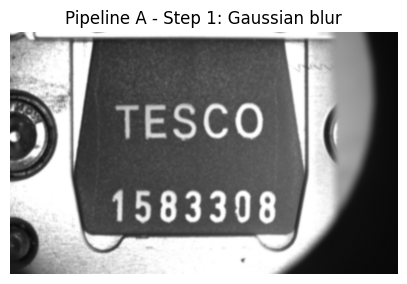

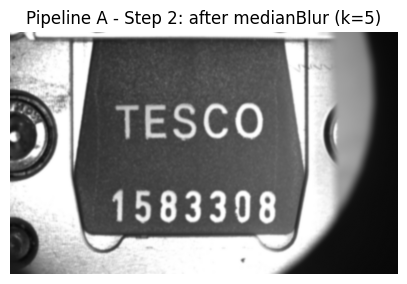

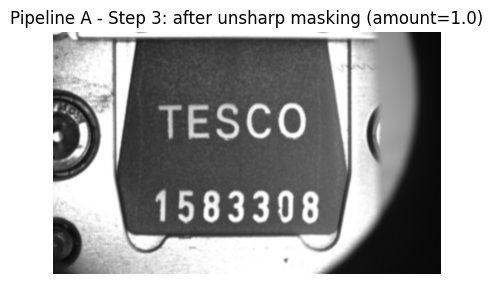

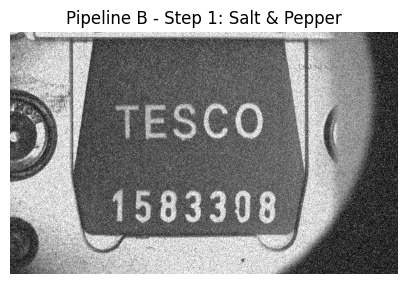

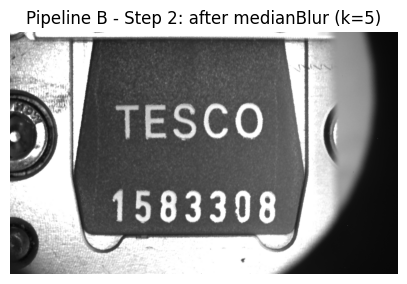

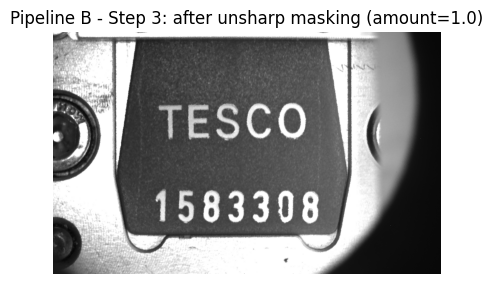

In [ ]:
rng = np.random.default_rng(seed)

original = cv2.imread(image_path, cv2.IMREAD_COLOR)
if original is None:
    raise FileNotFoundError(f"Failed to load image: {image_path}")

gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
show(gray, "Step 0: loaded image (grayscale)")

# === Pipeline A: Gaussian blur only ===
blurred = random_blur(gray, rng, max_blur_kernel_size, blur_probability)
show(blurred, "Pipeline A - Step 1: Gaussian blur")

denoised_a = cv2.medianBlur(blurred, median_kernel_size)
show(denoised_a, f"Pipeline A - Step 2: after medianBlur (k={median_kernel_size})")

sharpened_a = unsharp_mask(denoised_a, unsharp_kernel_size, unsharp_amount)
show(sharpened_a, f"Pipeline A - Step 3: after unsharp masking (amount={unsharp_amount})")

# === Pipeline B: Salt & Pepper only ===
noisy = add_salt_and_pepper_noise(
    gray, rng, (min_noise_amount, max_noise_amount), salt_ratio
)
show(noisy, "Pipeline B - Step 1: Salt & Pepper")

denoised_b = cv2.medianBlur(noisy, median_kernel_size)
show(denoised_b, f"Pipeline B - Step 2: after medianBlur (k={median_kernel_size})")

sharpened_b = unsharp_mask(denoised_b, unsharp_kernel_size, unsharp_amount)
show(sharpened_b, f"Pipeline B - Step 3: after unsharp masking (amount={unsharp_amount})")


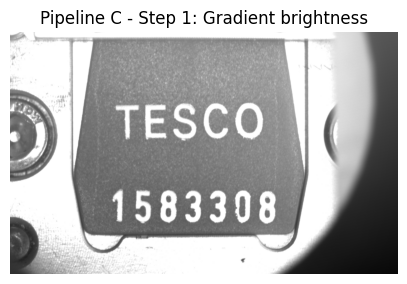

In [ ]:
gradient_img = add_gradient_brightness(
    gray, rng, (min_gradient_strength, max_gradient_strength)
)
show(gradient_img, "Pipeline C - Step 1: Gradient brightness")

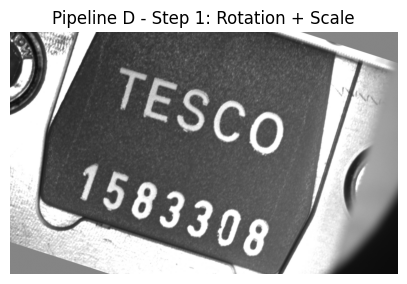

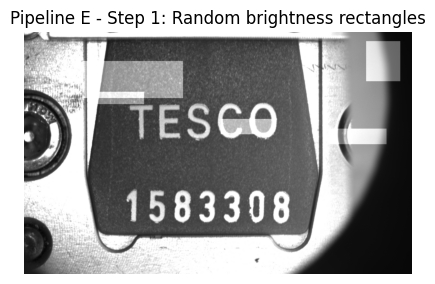

In [ ]:
rotated_scaled_img = random_rotate_scale(
    gray, rng, max_rotation_degrees, (min_scale, max_scale)
)
show(rotated_scaled_img, "Pipeline D - Step 1: Rotation + Scale")

# === Pipeline E: Random brightness rectangles only ===
rectangles_img = add_random_rectangles(
    gray, rng, (min_rectangles, max_rectangles),
    (min_rectangle_brightness, max_rectangle_brightness),
)
show(rectangles_img, "Pipeline E - Step 1: Random brightness rectangles")